In [88]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [89]:
df_train = pd.read_csv('adult.data.csv', skipinitialspace=True, na_values="?")
print(df_train.shape)
df_train.head()

(32561, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [90]:
df_test = pd.read_csv('adult.test.csv', skipinitialspace=True, na_values="?")
print(df_test.shape)
df_test.head()

(16281, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [91]:
df = pd.concat([df_train, df_test], ignore_index=True)
print(df.shape)
df

(48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K
48838,64,NaN,321403,HS-grad,9,Widowed,NaN,Other-relative,Black,Male,0,0,40,United-States,<=50K
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K


In [108]:
df['income'].value_counts()

income
0    34014
1    11208
Name: count, dtype: int64

## Обработка данных

In [92]:
df.isnull().sum()

age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
income               0
dtype: int64

In [93]:
df.dropna(inplace=True)
df.nunique()

age                  74
workclass             7
fnlwgt            26741
education            16
education-num        16
marital-status        7
occupation           14
relationship          6
race                  5
sex                   2
capital-gain        121
capital-loss         97
hours-per-week       96
native-country       41
income                2
dtype: int64

In [94]:
# Так как классификация бинарная, переведем целевую переменную в числовой формат: 0, 1
df['income'] = df['income'].map({'<=50K': 0, '>50K': 1})

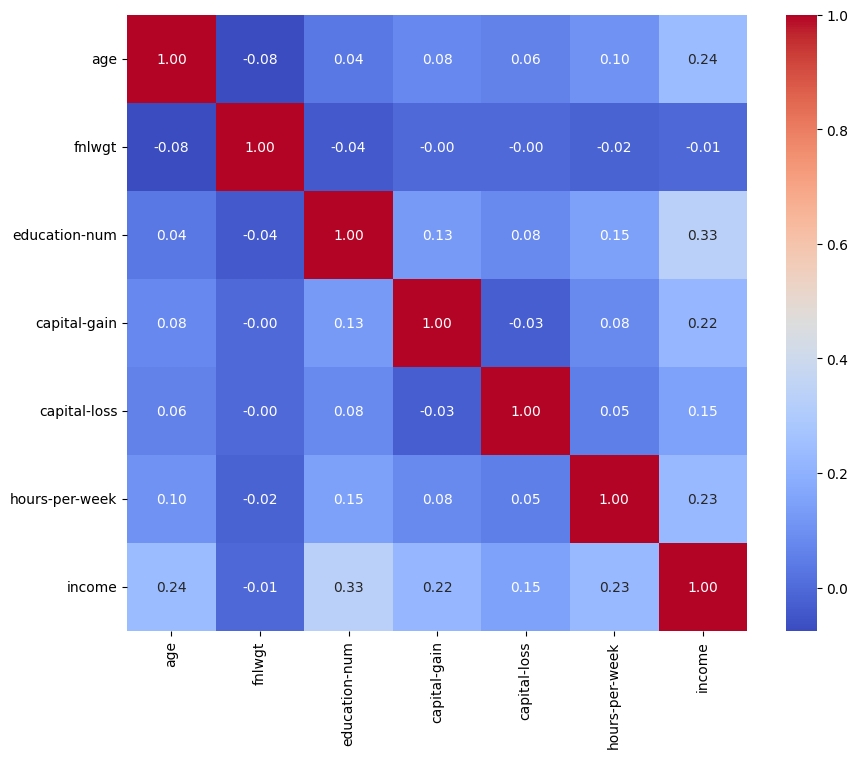

In [95]:
numeric_cols = df.select_dtypes(include='number').columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

## Выводы по анализу датасета
Признак fnlwgt очень слабо коррелирует с целевой переменной, а также у него очень много уникальных значений. Можно удалить.
Также, education_num является отображением education, поэтому один из признаков можно удалить.

In [96]:
df.drop(columns=['fnlwgt', 'education'], axis=1, inplace=True)

In [97]:
categorical_cols = [
    'workclass', 'marital-status',
    'occupation', 'relationship', 'race',
    'sex', 'native-country'
]

df = pd.get_dummies(df, columns=categorical_cols)

print(df.shape)
df

(45222, 88)


,age,education-num,capital-gain,capital-loss,hours-per-week,income,workclass_Federal-gov,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,39,13,2174,0,40,0,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,50,13,0,0,13,0,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,38,9,0,0,40,0,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
3,53,7,0,0,40,0,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
4,28,13,0,0,40,0,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48836,33,13,0,0,40,0,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
48837,39,13,0,0,36,0,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
48839,38,13,0,0,50,0,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
48840,44,13,5455,0,40,0,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False


In [98]:
X = df.drop("income", axis=1)
y = df["income"]

train_sizes = np.arange(0.6, 0.95, 0.05)

accuracy_list = []
precision_list = []
recall_list = []
f1_list = []
results = []

for train_size in train_sizes:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, train_size=train_size, random_state=42, stratify=y
    )
    
    model = GaussianNB()
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    results.append({
            "Train Size": train_size,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1-score": f1_score(y_test, y_pred)
        })
    
# Вывод таблицы результатов
results_df = pd.DataFrame(results)

results_df

,Train Size,Accuracy,Precision,Recall,F1-score
0,0.60,0.788601,0.550008,0.808387,0.654624
1,0.65,0.787149,0.547858,0.808310,0.653074
2,0.70,0.787868,0.549028,0.806068,0.653169
3,0.75,0.787900,0.549316,0.802998,0.652363
4,0.80,0.789276,0.551502,0.802409,0.653706
5,0.85,0.788473,0.550204,0.801904,0.652626
6,0.90,0.790405,0.552841,0.807315,0.656273


In [99]:
import json

# Сохраняем в JSON для следующей работы
with open('nb_results.json', 'w') as f:
    json.dump(results, f, indent=4)

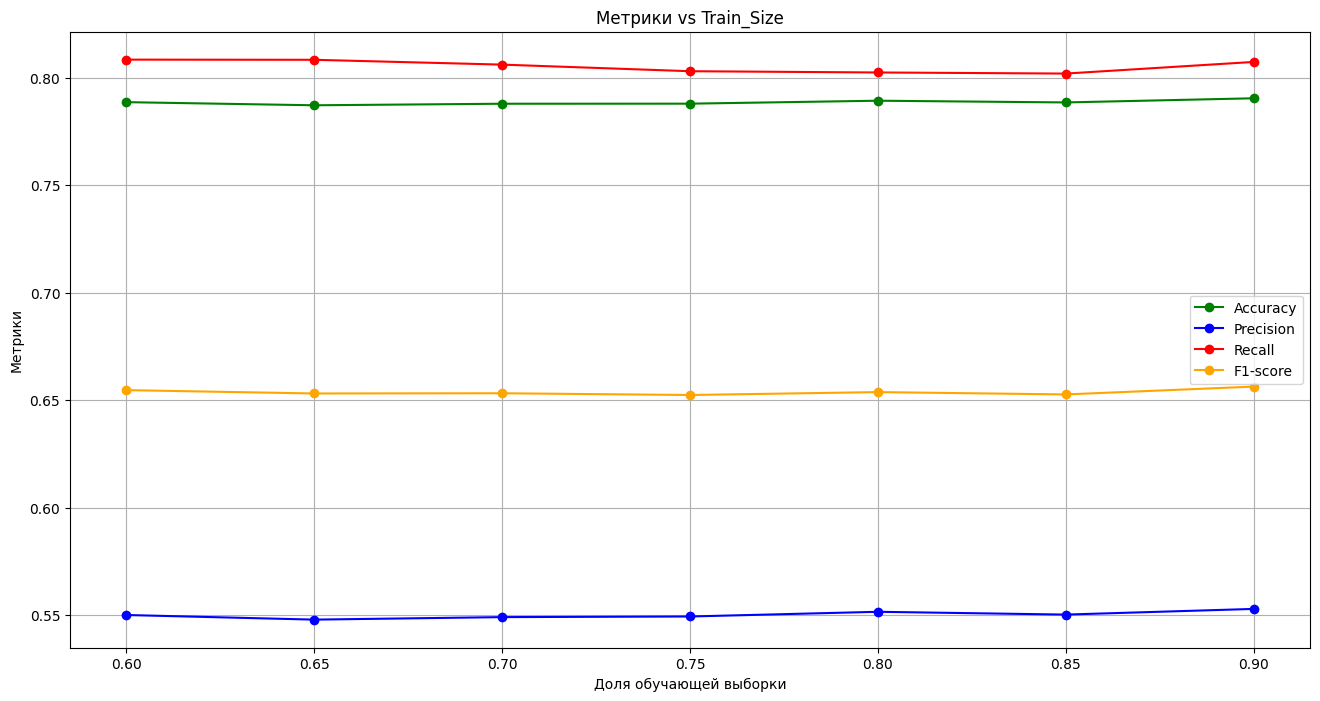

In [104]:
plt.figure(figsize=(16, 8))
plt.plot(train_sizes, results_df["Accuracy"], color="green", marker="o", label="Accuracy")
plt.plot(train_sizes, results_df["Precision"], color="blue", marker="o", label="Precision")
plt.plot(train_sizes, results_df["Recall"], color="red", marker="o", label="Recall")
plt.plot(train_sizes, results_df["F1-score"], color="orange", marker="o", label="F1-score")
plt.xlabel("Доля обучающей выборки")
plt.ylabel("Метрики")
plt.title("Метрики vs Train_Size")
plt.grid(True)
plt.legend()
plt.savefig('metrics_vs_train_size.png')
plt.show()

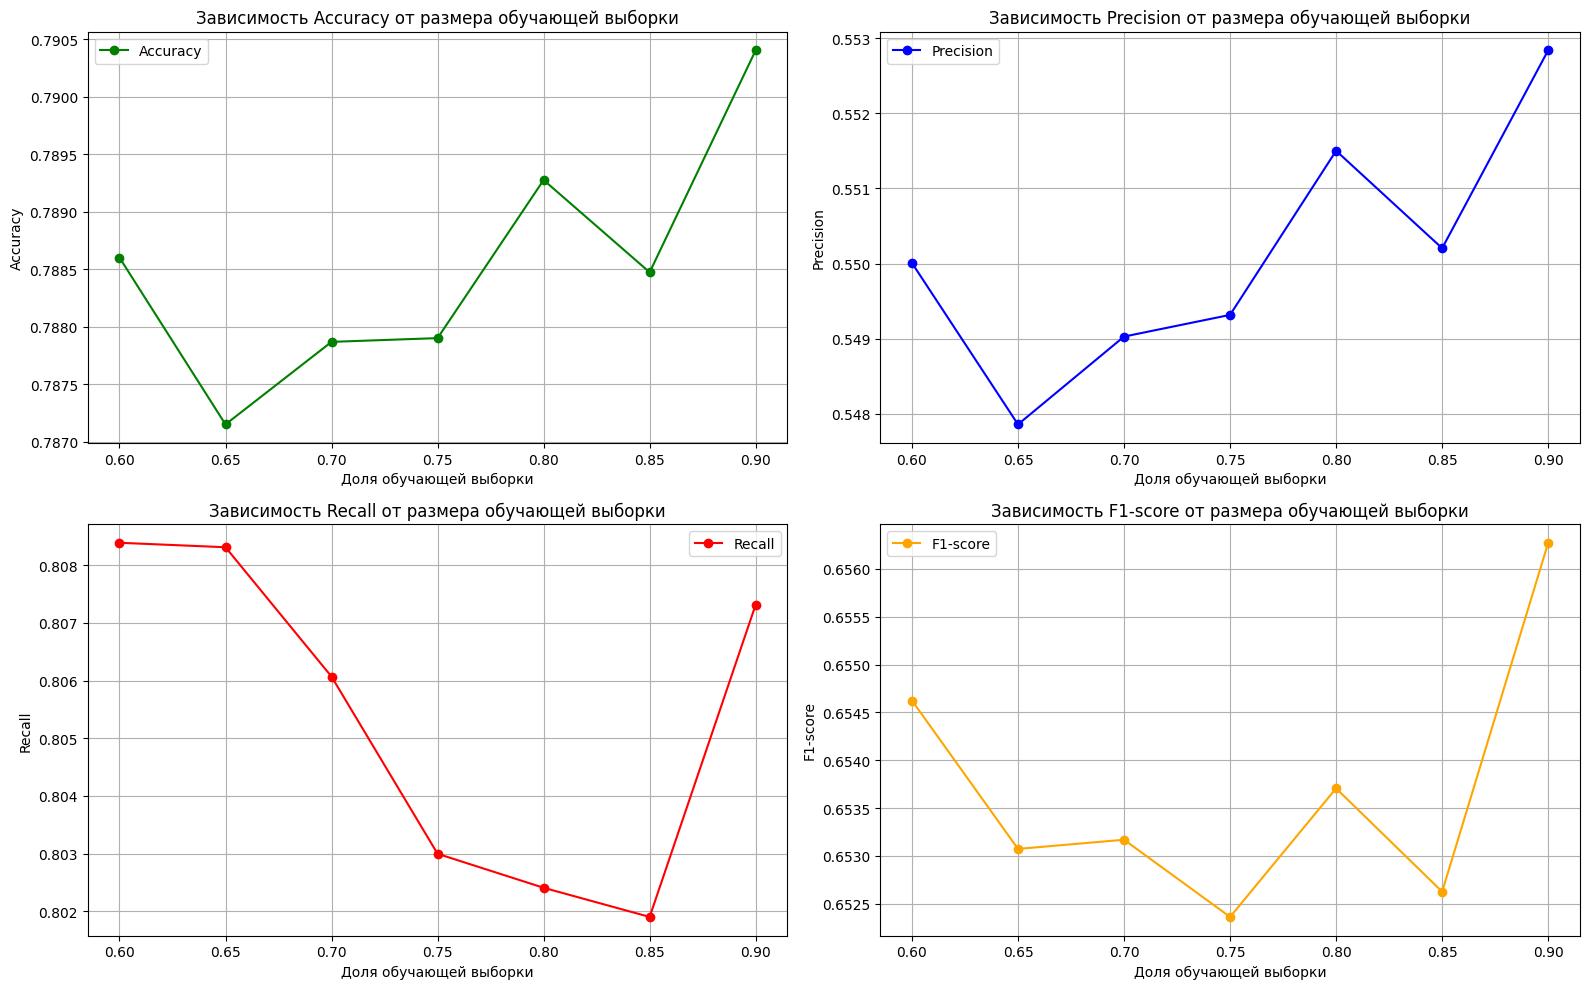

In [103]:
plt.figure(figsize=(16, 10))

# 1. Accuracy
plt.subplot(2, 2, 1)
plt.plot(train_sizes, results_df["Accuracy"], color="green", marker="o", label="Accuracy")
plt.xlabel("Доля обучающей выборки")
plt.ylabel("Accuracy")
plt.title("Зависимость Accuracy от размера обучающей выборки")
plt.grid(True)
plt.legend()

# 2. Precision
plt.subplot(2, 2, 2)
plt.plot(train_sizes, results_df["Precision"], color="blue", marker="o", label="Precision")
plt.xlabel("Доля обучающей выборки")
plt.ylabel("Precision")
plt.title("Зависимость Precision от размера обучающей выборки")
plt.grid(True)
plt.legend()

# 3. Recall
plt.subplot(2, 2, 3)
plt.plot(train_sizes, results_df["Recall"], color="red", marker="o", label="Recall")
plt.xlabel("Доля обучающей выборки")
plt.ylabel("Recall")
plt.title("Зависимость Recall от размера обучающей выборки")
plt.grid(True)
plt.legend()

# 4. F1-score
plt.subplot(2, 2, 4)
plt.plot(train_sizes, results_df["F1-score"], color="orange", marker="o", label="F1-score")
plt.xlabel("Доля обучающей выборки")
plt.ylabel("F1-score")
plt.title("Зависимость F1-score от размера обучающей выборки")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig('metrics_vs_train_size_subplots.png')
plt.show()